In [1]:
# ============================================
# Startup Cell: Mount Drive + Prepare Data
# ============================================

from google.colab import drive
drive.mount("/content/drive")

import os
import shutil

BASE_DRIVE_DIR = "/content/drive/MyDrive/DIP_Project"
CONTENT_DIR = "/content"
IMG_DIR = f"{CONTENT_DIR}/images"
ZIP_PATH = f"{BASE_DRIVE_DIR}/images.zip"

INPUT_FILES = [
    "train_metadata.csv",
    "validation_metadata.csv",
    "test_metadata.csv",
]

# --------------------------------------------
# Copy metadata CSVs to /content
# --------------------------------------------

print("Copying metadata CSV files...")

for filename in INPUT_FILES:
    src = os.path.join(BASE_DRIVE_DIR, filename)
    dst = os.path.join(CONTENT_DIR, filename)

    if not os.path.exists(src):
        raise FileNotFoundError(f"Missing source file: {src}")

    shutil.copy(src, dst)
    print(f"Copied: {filename}")

print("\nMetadata CSVs copied.")

# --------------------------------------------
# Unzip images if needed
# --------------------------------------------

if not os.path.exists(IMG_DIR):
    print("Creating images directory and unzipping...")
    os.makedirs(IMG_DIR, exist_ok=True)

    local_zip = os.path.join(CONTENT_DIR, "images.zip")
    shutil.copy(ZIP_PATH, local_zip)

    !unzip -q "/content/images.zip" -d "/content/"

    files_in_root = [
        f for f in os.listdir("/content")
        if f.endswith((".png", ".jpg", ".jpeg"))
    ]

    if len(files_in_root) > 0:
        print("Fixing structure: moving images into /content/images/")
        for f in files_in_root:
            shutil.move(f"/content/{f}", f"{IMG_DIR}/{f}")
else:
    print("Images already present.")

# --------------------------------------------
# Verification
# --------------------------------------------

print("\nVerification:")
print("Images:", len(os.listdir(IMG_DIR)))
for filename in INPUT_FILES:
    print(f"{filename} exists:", os.path.exists(os.path.join(CONTENT_DIR, filename)))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying metadata CSV files...
Copied: train_metadata.csv
Copied: validation_metadata.csv
Copied: test_metadata.csv

Metadata CSVs copied.
Images already present.

Verification:
Images: 12000
train_metadata.csv exists: True
validation_metadata.csv exists: True
test_metadata.csv exists: True


In [2]:
# ============================================
# Cell 0: Notebook Overview
# ============================================
# Purpose:
#   This notebook explores and verifies gradient-based feature extraction
#   using a selected split of the preprocessed image dataset.
#
# Inputs:
#   The notebook expects:
#     - split-specific metadata CSV file:
#         /content/train_metadata.csv
#         /content/validation_metadata.csv
#         /content/test_metadata.csv
#     - shared preprocessed image directory containing all 12000 images:
#         /content/images/
#
# Assumptions:
#   - The shared image directory contains all 12000 preprocessed images.
#   - The selected metadata CSV identifies which images belong to the
#     chosen dataset split.
#   - All images have already been preprocessed.
#   - All images are already grayscale.
#   - All images have already been resized to 256 x 256.
#   - This notebook does NOT perform resizing or grayscale conversion.
#   - This notebook focuses only on gradient-based feature extraction.
#   - Class labels are taken from metadata, not inferred from filenames.
#   - Expected split sizes are:
#       - train: 8400 images
#       - validation: 1800 images
#       - test: 1800 images
#
# What the notebook does:
#   Cell 1:
#     Import required libraries for image loading, numerical processing,
#     feature extraction, and visualization.
#
#   Cell 2:
#     Define the selected split, input paths, output path, and sample
#     image placeholders for exploratory analysis.
#
#   Cell 3:
#     Verify required inputs exist before processing:
#       - confirm the selected metadata CSV exists
#       - confirm /content/images/ directory exists
#       - confirm image files are present
#       - confirm metadata has expected columns and expected row count
#         for the selected split
#       - select the first image listed in the metadata CSV as the
#         sample image
#       - confirm sample image filenames match actual files
#
#   Cell 4:
#     Load the selected preprocessed image and verify its properties,
#     including:
#       - shape
#       - datatype
#       - intensity range
#
#   Cell 5:
#     Define helper functions for:
#       - entropy computation
#       - Sobel gradient computation
#       - gradient-based feature extraction
#
#   Cell 6:
#     Compute:
#       - horizontal gradient (Gx)
#       - vertical gradient (Gy)
#       - gradient magnitude
#       - gradient orientation
#       - edge mask based on gradient magnitude thresholding
#
#   Cell 7:
#     Display intermediate visual results for the sample image:
#       - input image
#       - Gx
#       - Gy
#       - gradient magnitude
#       - gradient orientation
#       - edge mask
#
#   Cell 8:
#     Plot histograms of:
#       - gradient magnitude
#       - gradient orientation
#
#   Cell 9:
#     Repeat the same analysis on a small set of additional images from
#     the selected split to compare real and AI-generated examples.
#
#   Cell 10:
#     Apply gradient-based feature extraction to all images identified by
#     the selected metadata CSV and save the results to a split-specific
#     output file:
#       /content/train_gradient_features.csv
#       /content/validation_gradient_features.csv
#       /content/test_gradient_features.csv
#
# Outputs:
#   Primary output:
#     - visual validation of gradient extraction behavior
#     - printed gradient-based feature values for selected images
#
#   Optional CSV output:
#     - /content/train_gradient_features.csv
#     - /content/validation_gradient_features.csv
#     - /content/test_gradient_features.csv
#
# Notes:
#   - This is an exploratory notebook intended to verify correctness
#     before scaling to full-dataset feature extraction.
#   - Only images listed in the selected metadata CSV are used for
#     feature extraction, even though /content/images/ contains all
#     12000 preprocessed images.
#   - Only gradient-based features are extracted in this notebook.
#   - Later work can combine gradient, spatial, and frequency-domain
#     features into a single dataset for classifier training and
#     evaluation.
#   - The same notebook structure and functionality are preserved while
#     allowing selection of the train, validation, or test split.
# ============================================

print("Notebook overview loaded.")



Notebook overview loaded.


In [3]:
# ============================================
# Cell 1: Imports
# ============================================

import os

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import matplotlib.pyplot as plt

from scipy.stats import entropy

print("Libraries imported successfully.")



Libraries imported successfully.


In [4]:
# ============================================
# Cell 2: Define Input Paths and Sample Image
# ============================================

import os

# -------------------------------------------------
# Select dataset split
# -------------------------------------------------
SPLIT_NAME = "train"   # options: "train", "validation", "test"

# -------------------------------------------------
# Define paths
# -------------------------------------------------
METADATA_CSV = f"/content/{SPLIT_NAME}_metadata.csv"
IMG_DIR = "/content/images"

# Output CSV (for full dataset extraction)
OUTPUT_CSV = f"/content/{SPLIT_NAME}_gradient_features.csv"

# -------------------------------------------------
# Expected row counts (for validation in Cell 3)
# -------------------------------------------------
EXPECTED_ROWS = {
    "train": 8400,
    "validation": 1800,
    "test": 1800
}

# -------------------------------------------------
# Sample image (set in Cell 3 after loading metadata)
# -------------------------------------------------
SAMPLE_FILENAME = None
SAMPLE_IMAGE_PATH = None

# -------------------------------------------------
# Display configuration
# -------------------------------------------------
print("SPLIT_NAME      =", SPLIT_NAME)
print("METADATA_CSV    =", METADATA_CSV)
print("IMG_DIR         =", IMG_DIR)
print("OUTPUT_CSV      =", OUTPUT_CSV)
print("EXPECTED_ROWS   =", EXPECTED_ROWS[SPLIT_NAME])
print("SAMPLE_IMAGE    =", SAMPLE_IMAGE_PATH)



SPLIT_NAME      = test
METADATA_CSV    = /content/test_metadata.csv
IMG_DIR         = /content/images
OUTPUT_CSV      = /content/test_gradient_features.csv
EXPECTED_ROWS   = 1800
SAMPLE_IMAGE    = None


In [5]:
# ============================================
# Cell 3: Input Validation
# ============================================

# --- Check metadata CSV ---
assert os.path.exists(METADATA_CSV), f"Missing file: {METADATA_CSV}"
print(f"PASS: Found metadata CSV -> {METADATA_CSV}")

# --- Check shared image directory ---
assert os.path.isdir(IMG_DIR), f"Missing directory: {IMG_DIR}"
print(f"PASS: Found image directory -> {IMG_DIR}")

# --- Check image files exist in shared directory ---
image_files = os.listdir(IMG_DIR)
assert len(image_files) > 0, "No images found in shared image directory"
print(f"PASS: Found {len(image_files)} files in image directory")

# --- Load selected-split metadata ---
df = pd.read_csv(METADATA_CSV)
print(f"PASS: Loaded metadata CSV with shape {df.shape}")

# --- Check expected row count ---
assert df.shape[0] == EXPECTED_ROWS[SPLIT_NAME], (
    f"Expected {EXPECTED_ROWS[SPLIT_NAME]} rows for {SPLIT_NAME}, "
    f"found {df.shape[0]}"
)
print(f"PASS: Metadata contains expected {EXPECTED_ROWS[SPLIT_NAME]} {SPLIT_NAME} rows")

# --- Check required columns ---
required_cols = ["filename", "class_label", "source_dataset"]
for col in required_cols:
    assert col in df.columns, f"Missing required column: {col}"
print("PASS: Required columns present")


# --- Check subset column and values ---
assert "subset" in df.columns, "Missing required column: subset"
unique_subsets = sorted(df["subset"].dropna().unique().tolist())
assert unique_subsets == [SPLIT_NAME], (
    f"Expected subset column to contain only [{SPLIT_NAME}], got {unique_subsets}"
)
print(f"PASS: Subset column matches selected split -> {SPLIT_NAME}")

# --- Select sample image (first row of metadata) ---
SAMPLE_FILENAME = df["filename"].iloc[0]
SAMPLE_IMAGE_PATH = os.path.join(IMG_DIR, SAMPLE_FILENAME)

assert os.path.exists(SAMPLE_IMAGE_PATH), f"Sample image not found: {SAMPLE_FILENAME}"
print(f"PASS: Sample image selected -> {SAMPLE_FILENAME}")

# --- Check a few metadata filenames exist in shared image directory ---
missing_files = []
for fname in df["filename"].head(10):
    fpath = os.path.join(IMG_DIR, fname)
    if not os.path.exists(fpath):
        missing_files.append(fname)

assert len(missing_files) == 0, f"Missing image files: {missing_files}"
print(f"PASS: Sample {SPLIT_NAME} metadata image files exist")

print("\nAll input validation checks passed.")


PASS: Found metadata CSV -> /content/test_metadata.csv
PASS: Found image directory -> /content/images
PASS: Found 12000 files in image directory
PASS: Loaded metadata CSV with shape (1800, 5)
PASS: Metadata contains expected 1800 test rows
PASS: Required columns present
PASS: Subset column matches selected split -> test
PASS: Sample image selected -> ai_sdxl_002433.png
PASS: Sample test metadata image files exist

All input validation checks passed.


Inspecting sample image from test split: ai_sdxl_002433.png
Shape: (256, 256)
Dtype: float32
Min: 0.019607843831181526
Max: 0.9450980424880981
Mean: 0.49633562564849854
Std: 0.2021290361881256


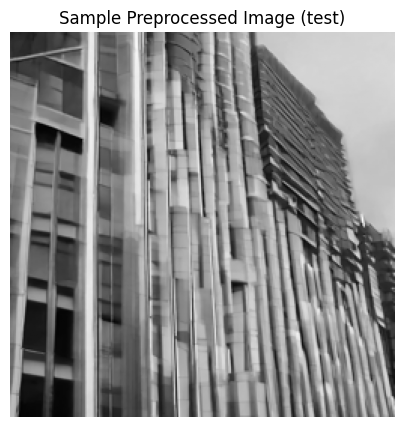

In [6]:
# ============================================
# Cell 4: Load and Inspect Sample Image
# ============================================

def load_preprocessed_image(image_path):
    img = Image.open(image_path)
    img = np.array(img)

    if img.ndim == 3 and img.shape[2] == 1:
        img = img[:, :, 0]
    elif img.ndim != 2:
        raise ValueError(f"Expected grayscale image, got shape {img.shape}")

    img = img.astype(np.float32)

    if img.max() > 1.0:
        img = img / 255.0

    return img


def inspect_image(img):
    print("Shape:", img.shape)
    print("Dtype:", img.dtype)
    print("Min:", float(img.min()))
    print("Max:", float(img.max()))
    print("Mean:", float(img.mean()))
    print("Std:", float(img.std()))


# Load sample image selected in Cell 3
img = load_preprocessed_image(SAMPLE_IMAGE_PATH)

print(f"Inspecting sample image from {SPLIT_NAME} split: {SAMPLE_FILENAME}")
inspect_image(img)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title(f"Sample Preprocessed Image ({SPLIT_NAME})")
plt.axis("off")
plt.show()



In [7]:
# ============================================
# Cell 5: Gradient and Feature Helper Functions
# ============================================

def safe_entropy_from_hist(hist, eps=1e-12):
    hist = hist.astype(np.float64)
    hist = hist / (hist.sum() + eps)
    hist = np.clip(hist, eps, None)
    return float(entropy(hist, base=2))


def compute_gradients(img):
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)

    mag = np.sqrt(gx ** 2 + gy ** 2)
    ori = np.arctan2(gy, gx)

    return gx, gy, mag, ori


def extract_gradient_features(img):
    gx, gy, mag, ori = compute_gradients(img)

    mean_grad = float(np.mean(mag))
    std_grad = float(np.std(mag))
    max_grad = float(np.max(mag))

    mag_max = max(float(mag.max()), 1e-6)
    mag_hist, _ = np.histogram(mag.ravel(), bins=64, range=(0.0, mag_max))
    grad_entropy = safe_entropy_from_hist(mag_hist)

    edge_threshold = np.mean(mag) + np.std(mag)
    edge_mask = mag > edge_threshold
    edge_density = float(np.mean(edge_mask))

    ori_hist, _ = np.histogram(ori.ravel(), bins=36, range=(-np.pi, np.pi))
    ori_entropy = safe_entropy_from_hist(ori_hist)

    features = {
        "Mean Gradient": mean_grad,
        "Std Gradient": std_grad,
        "Max Gradient": max_grad,
        "Gradient Entropy": grad_entropy,
        "Edge Density": edge_density,
        "Orientation Mean": float(np.mean(ori)),
        "Orientation Std": float(np.std(ori)),
        "Orientation Entropy": ori_entropy,
    }

    return features, gx, gy, mag, ori, edge_mask


print("Gradient helper functions defined.")



Gradient helper functions defined.


In [8]:
# ============================================
# Cell 6: Compute Gradient Components
# ============================================

features, gx, gy, mag, ori, edge_mask = extract_gradient_features(img)

print(f"Gradient components computed successfully for {SPLIT_NAME} sample image.")
print("Gx shape          =", gx.shape)
print("Gy shape          =", gy.shape)
print("Magnitude shape   =", mag.shape)
print("Orientation shape =", ori.shape)
print("Edge mask shape   =", edge_mask.shape)



Gradient components computed successfully for test sample image.
Gx shape          = (256, 256)
Gy shape          = (256, 256)
Magnitude shape   = (256, 256)
Orientation shape = (256, 256)
Edge mask shape   = (256, 256)


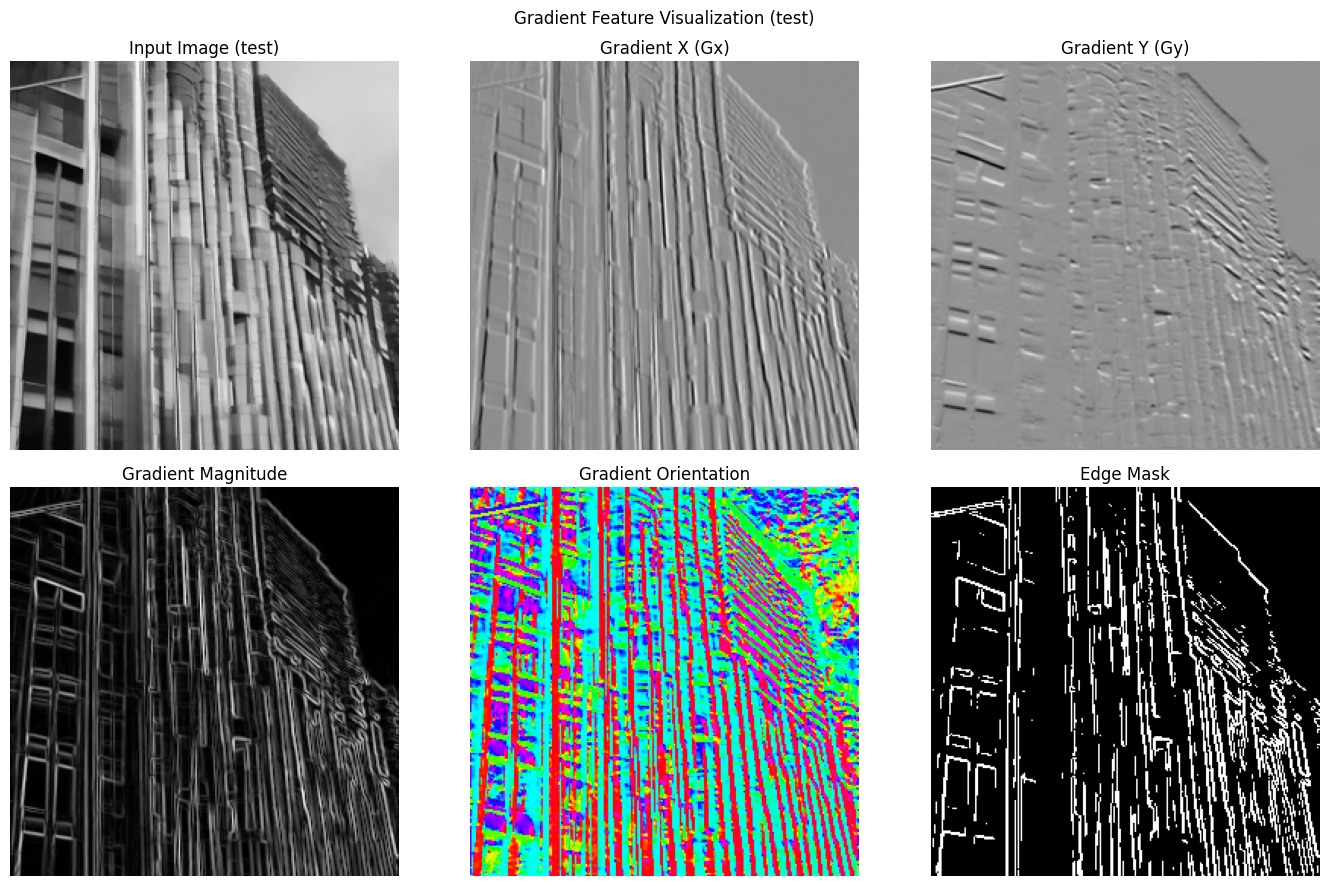

In [9]:
# ============================================
# Cell 7: Display Gradient Visualization Results
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title(f"Input Image ({SPLIT_NAME})")
axes[0, 0].axis("off")

axes[0, 1].imshow(gx, cmap="gray")
axes[0, 1].set_title("Gradient X (Gx)")
axes[0, 1].axis("off")

axes[0, 2].imshow(gy, cmap="gray")
axes[0, 2].set_title("Gradient Y (Gy)")
axes[0, 2].axis("off")

axes[1, 0].imshow(mag, cmap="gray")
axes[1, 0].set_title("Gradient Magnitude")
axes[1, 0].axis("off")

axes[1, 1].imshow(ori, cmap="hsv")
axes[1, 1].set_title("Gradient Orientation")
axes[1, 1].axis("off")

axes[1, 2].imshow(edge_mask, cmap="gray")
axes[1, 2].set_title("Edge Mask")
axes[1, 2].axis("off")

plt.suptitle(f"Gradient Feature Visualization ({SPLIT_NAME})", fontsize=12)
plt.tight_layout()
plt.show()



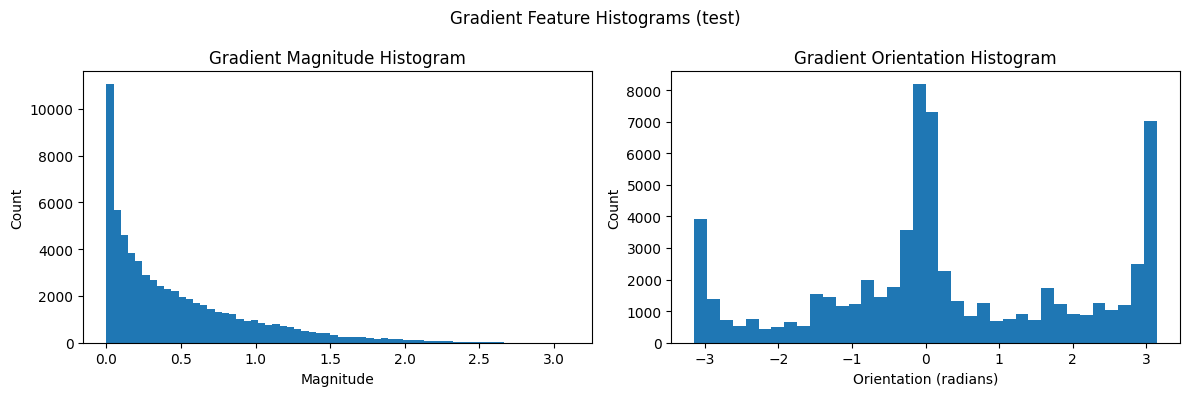

In [10]:
# ============================================
# Cell 8: Plot Gradient Histograms
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mag.ravel(), bins=64)
axes[0].set_title("Gradient Magnitude Histogram")
axes[0].set_xlabel("Magnitude")
axes[0].set_ylabel("Count")

axes[1].hist(ori.ravel(), bins=36, range=(-np.pi, np.pi))
axes[1].set_title("Gradient Orientation Histogram")
axes[1].set_xlabel("Orientation (radians)")
axes[1].set_ylabel("Count")

plt.suptitle(f"Gradient Feature Histograms ({SPLIT_NAME})", fontsize=12)
plt.tight_layout()
plt.show()



In [11]:
# ============================================
# Cell 9: Print Gradient Feature Values
# ============================================

print(f"Gradient Feature Values ({SPLIT_NAME})")
print(f"Sample Image: {SAMPLE_FILENAME}\n")

for k, v in features.items():
    print(f"{k:25s}: {v:.6f}")

Gradient Feature Values (test)
Sample Image: ai_sdxl_002433.png

Mean Gradient            : 0.474369
Std Gradient             : 0.486565
Max Gradient             : 3.098675
Gradient Entropy         : 4.683932
Edge Density             : 0.156845
Orientation Mean         : 0.254441
Orientation Std          : 1.782731
Orientation Entropy      : 4.634840


Selected images from test split:
          filename class_label     source_dataset
rl_coco_001435.png        real       MS_COCO_2017
rl_imgn_001596.png        real    ImageNet_1K_256
ai_diff_000460.png          ai        DiffusionDB
ai_sdxl_000002.png          ai SDXL_Generated_10K

Class counts:
class_label
real    2
ai      2

Total selected: 4

TEST | Image 1 of 4
Filename: rl_coco_001435.png
Label: real | Source: MS_COCO_2017
Mean Gradient            : 0.240074
Std Gradient             : 0.296251
Max Gradient             : 3.234807
Gradient Entropy         : 3.609279
Edge Density             : 0.115128
Orientation Mean         : -0.042708
Orientation Std          : 1.873210
Orientation Entropy      : 5.143116


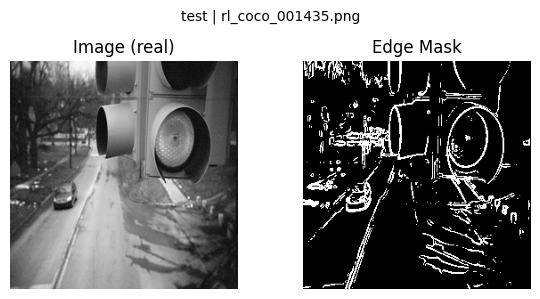


TEST | Image 2 of 4
Filename: rl_imgn_001596.png
Label: real | Source: ImageNet_1K_256
Mean Gradient            : 0.231970
Std Gradient             : 0.298856
Max Gradient             : 3.268383
Gradient Entropy         : 3.418527
Edge Density             : 0.077972
Orientation Mean         : 0.004217
Orientation Std          : 1.784270
Orientation Entropy      : 5.158517


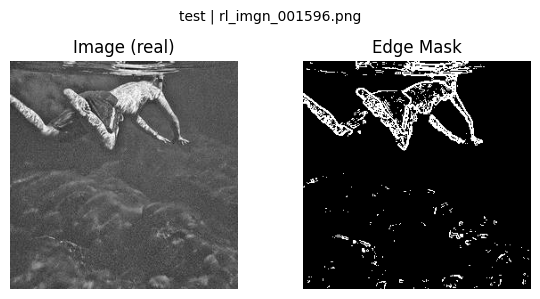


TEST | Image 3 of 4
Filename: ai_diff_000460.png
Label: ai | Source: DiffusionDB
Mean Gradient            : 0.324057
Std Gradient             : 0.292236
Max Gradient             : 2.674797
Gradient Entropy         : 4.355513
Edge Density             : 0.134415
Orientation Mean         : -0.036737
Orientation Std          : 1.809893
Orientation Entropy      : 5.163143


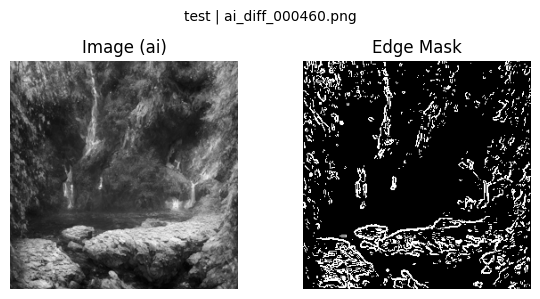


TEST | Image 4 of 4
Filename: ai_sdxl_000002.png
Label: ai | Source: SDXL_Generated_10K
Mean Gradient            : 0.267585
Std Gradient             : 0.280870
Max Gradient             : 2.329617
Gradient Entropy         : 4.302832
Edge Density             : 0.134979
Orientation Mean         : 0.264321
Orientation Std          : 1.808957
Orientation Entropy      : 5.124689


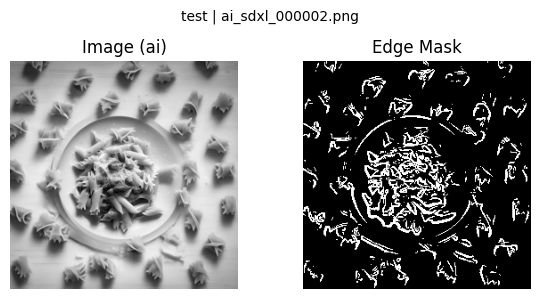

In [12]:
# ============================================
# Cell 10: Compare Real vs AI Images
# ============================================

# Select 2 real and 2 AI images (safe sampling)
df_real = df[df["class_label"] == "real"].sample(
    n=min(2, len(df[df["class_label"] == "real"])),
    random_state=42
)
df_ai = df[df["class_label"] == "ai"].sample(
    n=min(2, len(df[df["class_label"] == "ai"])),
    random_state=42
)

sample_df = pd.concat([df_real, df_ai], axis=0).reset_index(drop=True)

print(f"Selected images from {SPLIT_NAME} split:")
print(sample_df[["filename", "class_label", "source_dataset"]].to_string(index=False))
print("\nClass counts:")
print(sample_df["class_label"].value_counts().to_string())
print("\nTotal selected:", len(sample_df))

for i, row in sample_df.iterrows():
    fname = row["filename"]
    label = row["class_label"]
    source = row["source_dataset"]

    image_path = os.path.join(IMG_DIR, fname)

    img_sample = load_preprocessed_image(image_path)
    features_sample, gx_s, gy_s, mag_s, ori_s, edge_s = extract_gradient_features(img_sample)

    print("\n============================================")
    print(f"{SPLIT_NAME.upper()} | Image {i+1} of {len(sample_df)}")
    print(f"Filename: {fname}")
    print(f"Label: {label} | Source: {source}")

    for k, v in features_sample.items():
        print(f"{k:25s}: {v:.6f}")

    plt.figure(figsize=(6, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(img_sample, cmap="gray")
    plt.title(f"Image ({label})")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(edge_s, cmap="gray")
    plt.title("Edge Mask")
    plt.axis("off")

    plt.suptitle(f"{SPLIT_NAME} | {fname}", fontsize=10)
    plt.tight_layout()
    plt.show()



In [13]:
# ============================================
# Cell 11: Batch Gradient Feature Extraction
# ============================================

rows = []

for _, row in df.iterrows():
    fname = row["filename"]
    image_path = os.path.join(IMG_DIR, fname)

    try:
        img_batch = load_preprocessed_image(image_path)
        features_batch, _, _, _, _, _ = extract_gradient_features(img_batch)

        out_row = row.to_dict()
        out_row.update(features_batch)

        rows.append(out_row)

    except Exception as e:
        print(f"Skipping {fname}: {e}")

features_df = pd.DataFrame(rows)

features_df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved: {OUTPUT_CSV}")
print("Shape:", features_df.shape)
print(f"Processed split: {SPLIT_NAME}")



Saved: /content/test_gradient_features.csv
Shape: (1800, 13)
Processed split: test
